In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Veri setini indir veya yükle
url = "/content/drive/MyDrive/KAIRU/Kurumsal/Acun Medya Eğitimi/datasets/Advertising.csv"
data = pd.read_csv(url)

# İlk birkaç satırı inceleyelim
print(data.head())


   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [11]:
# Gereksiz sütunları kaldır
data = data.drop(columns=["Unnamed: 0"], axis=1)

# Veri hakkında bilgi
print(data.info())

# Temel istatistikler
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


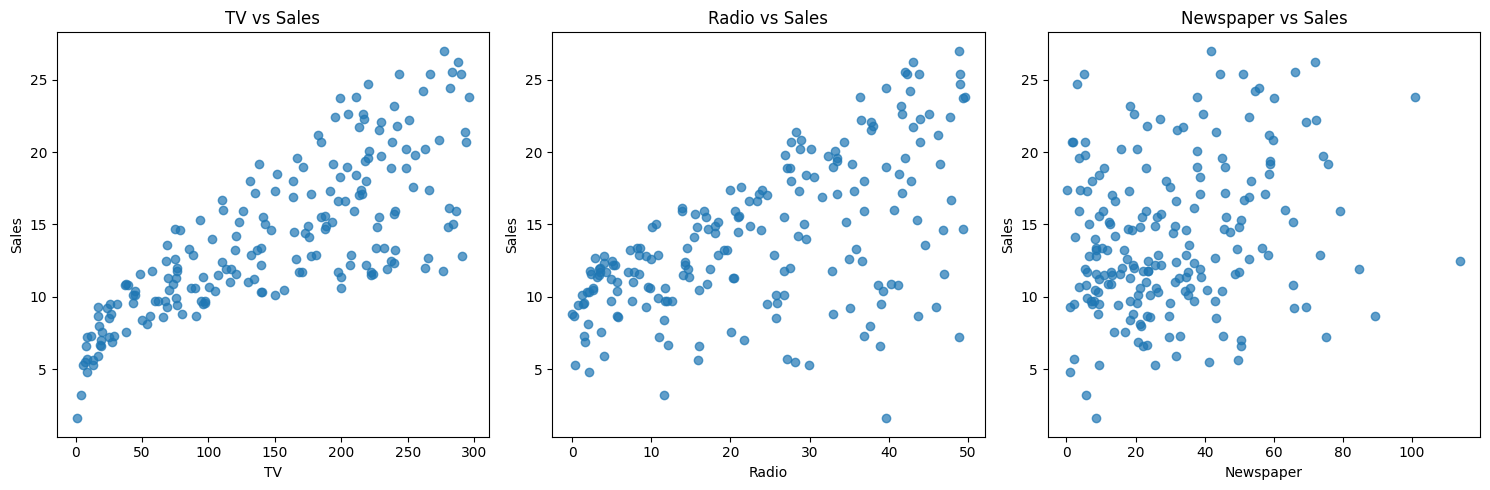

In [12]:
# Özellikler ile satışlar arasındaki ilişkiyi görselleştir
plt.figure(figsize=(15, 5))

for i, column in enumerate(['TV', 'Radio', 'Newspaper']):
    plt.subplot(1, 3, i + 1)
    plt.scatter(data[column], data['Sales'], alpha=0.7)
    plt.title(f"{column} vs Sales")
    plt.xlabel(column)
    plt.ylabel("Sales")

plt.tight_layout()
plt.show()


In [13]:
# Bağımsız ve bağımlı değişkenleri belirle
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

# Veri setini eğitim ve test olarak ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluştur ve eğit
model = LinearRegression()
model.fit(X_train, y_train)

# Tahmin yap
y_pred = model.predict(X_test)

# Model performansını değerlendirme
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R-squared (R²):", r2_score(y_test, y_pred))


Model Coefficients: [0.04472952 0.18919505 0.00276111]
Model Intercept: 2.979067338122629
Mean Squared Error (MSE): 3.1740973539761033
Root Mean Squared Error (RMSE): 1.78159966153345
Mean Absolute Error (MAE): 1.4607567168117603
R-squared (R²): 0.899438024100912


In [14]:
import joblib
# Modeli kaydetme
joblib.dump(model, "/content/drive/MyDrive/KAIRU/Kurumsal/Acun Medya Eğitimi/7.hafta_lineer_regresyon/advertising_model.joblib")
print("Model 'linear_regression_model.joblib' olarak kaydedildi.")

Model 'linear_regression_model.joblib' olarak kaydedildi.




### 1. **Model Coefficients** (Katsayılar):
   - **TV**: `0.04472952`
     - TV reklamlarına harcanan her bir birim (örneğin 1000 dolar), satışlarda yaklaşık **0.045 birimlik bir artış**a neden oluyor. TV harcamalarının satışlara en güçlü etkiye sahip olduğu görülüyor.
   - **Radio**: `0.18919505`
     - Radyo reklamlarına yapılan harcamalarda her bir birimlik artış, satışlarda yaklaşık **0.189 birimlik bir artış** sağlıyor. Radyo reklamları da satışlar üzerinde güçlü bir etkiye sahip.
   - **Newspaper**: `0.00276111`
     - Gazete reklamlarına yapılan harcamalarda her bir birimlik artış, satışlarda yalnızca **0.003 birimlik bir artış**a neden oluyor. Gazete reklamlarının etkisi oldukça düşük.

Bu sonuçlara göre TV ve radyo reklamlarına harcama yapmak satışlar üzerinde daha büyük bir etkiye sahipken, gazete reklamlarının etkisi ihmal edilebilir seviyede.

---

### 2. **Model Intercept** (Y Ön Belirleme Değeri):
   - **Intercept**: `2.979067338122629`
     - Tüm bağımsız değişkenlerin (TV, radyo, gazete) sıfır olduğu durumda, modelimiz satışların yaklaşık **2.98 birim** olacağını tahmin ediyor. Bu, başlangıç seviyesi satışlar olarak düşünülebilir.

---

### 3. **Mean Squared Error (MSE)**:
   - **MSE**: `3.1740973539761033`
     - Bu değer, modelin tahmin hatasının karesinin ortalamasını ifade eder. MSE'nin daha düşük olması, modelin daha iyi performans gösterdiği anlamına gelir. Ancak bu değer tek başına yorumlanmamalıdır, veri setindeki satış değerlerinin dağılımına bağlıdır.

---

### 4. **R-squared (R²)**:
   - **R²**: `0.899438024100912`
     - Bu değer, modelin satışlardaki değişkenliğin yaklaşık **%89.94**'ünü açıkladığını gösterir. Yani, TV, radyo ve gazete reklamları satışların %90'ına yakınını açıklamakta. R²'nin bu kadar yüksek olması, modelin iyi bir uyum sağladığını gösterir.

---

### Genel Yorum:
1. Model, TV ve radyo reklamlarının satışlar üzerindeki etkisini güçlü bir şekilde yakalamış. Gazete reklamlarının etkisinin çok düşük olduğu görülüyor.
2. Modelin R² değeri oldukça yüksek, bu da bağımsız değişkenlerin bağımlı değişken üzerindeki etkisinin güçlü olduğunu gösteriyor.
3. Gazete reklamlarının etkisinin bu kadar düşük olmasından dolayı, iş kararlarında gazete harcamalarını gözden geçirmek mantıklı olabilir.

### Öneriler:
- TV ve radyo reklamlarına yapılan yatırımı artırmak, satışları optimize etmek için daha faydalı olabilir.
- Gazete reklamlarının etkinliğini artırmak ya da bütçeyi başka alanlara kaydırmak değerlendirilebilir.
- Daha fazla özellik eklenerek (örneğin, çevrim içi reklam harcamaları veya bölgesel etkiler) modelin performansı iyileştirilebilir.

